# Unsupervised Learning

Two clustering tasks on the Sheffield Road Collision dataset:

| Task | Goal |
|------|------|
| A | Cluster collisions by road and environment conditions to identify risk profiles |
| B | Cluster by geographic coordinates to identify spatial accident hotspots |

Both tasks use KMeans and DBSCAN. KMeans k is selected via elbow method,
silhouette score, and Davies-Bouldin index. DBSCAN parameters are taken
from `config.yml`. All features are StandardScaled before clustering.

---
# 1. Configuration and Imports

In [1]:
import os
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')


def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')


ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':   nb_cfg['plotting']['figsize_wide'],
    'figsize_square': nb_cfg['plotting']['figsize_square'],
    'figsize_tall':   nb_cfg['plotting']['figsize_tall'],
    'palette':        nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Processed Data

In [2]:
df = pd.read_csv(ROOT_DIR / cfg['preprocessing']['output_path'])

print(f'Shape: {df.shape}')
df.head(3)

Shape: (7258, 32)


,collision_index,collision_year,location_easting_osgr,location_northing_osgr,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,local_authority_highway_current,first_road_class,...,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,collision_injury_based,hour_of_day,month,is_weekend,time_period,multi_vehicle
0,2.02E+12,2020,0.0,1.0,3,0.5,1,1,E08000019,4,...,0,0,1,2.0,1,15,12,1,1,0
1,201514K039415,2015,1.0,1.0,3,0.5,1,7,E08000019,3,...,0,0,1,2.0,0,11,2,1,0,0
2,201514K319315,2015,1.0,1.0,3,0.5,1,5,E08000019,4,...,0,0,1,2.0,0,18,11,0,2,0


---
# 3. Shared Utilities

In [3]:
def cluster_summary(labels, dataset_name):
    """Print cluster counts, noise percentage, and return a summary dict."""
    unique = sorted(set(labels))
    n_clusters = len([l for l in unique if l != -1])  # noqa: E741
    n_noise    = (labels == -1).sum() if -1 in unique else 0
    noise_pct  = n_noise / len(labels) * 100

    print(f'[{dataset_name}]')
    print(f'  Clusters found: {n_clusters}')
    print(f'  Noise points:   {n_noise} ({noise_pct:.1f}%)')
    for cl in unique:
        if cl == -1:
            continue
        count = (labels == cl).sum()
        print(f'  Cluster {cl}: {count:,} points ({count/len(labels)*100:.1f}%)')
    return {'n_clusters': n_clusters, 'n_noise': n_noise, 'noise_pct': noise_pct}

---
# Task A - Collision Risk Clustering

**Features:** `number_of_casualties`, `number_of_vehicles`, `speed_limit`,
`road_type`, `weather_conditions`, `light_conditions`, `road_surface_conditions`.

Each cluster represents a group of collisions that occurred under similar
road and environmental conditions, helping identify distinct risk profiles.

## A.1 Feature Selection and Scaling

In [4]:
unsup_cfg = cfg['unsupervised']

feature_cols_a = [
    'number_of_casualties',
    'number_of_vehicles',
    'speed_limit',
    'road_type',
    'weather_conditions',
    'light_conditions',
    'road_surface_conditions',
]

available_a = [c for c in feature_cols_a if c in df.columns]
missing_a   = [c for c in feature_cols_a if c not in df.columns]
if missing_a:
    print(f'WARNING: columns not found: {missing_a}')

X_a = df[available_a].dropna().copy()
print(f'Task A feature matrix: {X_a.shape}')
print(f'Features: {available_a}')

Task A feature matrix: (7258, 7)
Features: ['number_of_casualties', 'number_of_vehicles', 'speed_limit', 'road_type', 'weather_conditions', 'light_conditions', 'road_surface_conditions']


In [5]:
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a)
print('StandardScaler applied.')
print(f'Mean (should be ~0): {X_a_scaled.mean(axis=0).round(3)}')
print(f'Std  (should be ~1): {X_a_scaled.std(axis=0).round(3)}')

StandardScaler applied.
Mean (should be ~0): [ 0.  0.  0.  0.  0. -0.  0.]
Std  (should be ~1): [0. 0. 1. 1. 1. 1. 1.]


## A.2 PCA - Dimensionality Reduction

PCA is applied for two purposes: explained variance analysis (how many
components are needed to retain 80%/95% of variance) and 2D projection
for cluster visualization.

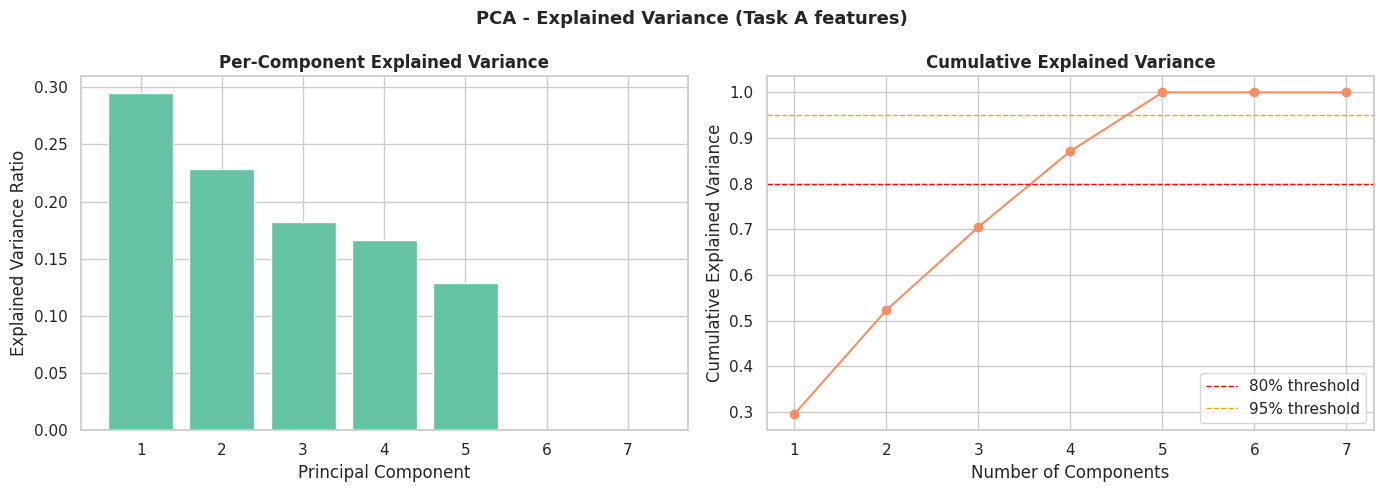

Components for 80% variance: 4
Components for 95% variance: 5


In [6]:
pca = PCA(random_state=unsup_cfg['random_state'])
pca.fit(X_a_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))
palette = sns.color_palette(NB_CONFIG['palette'])

axes[0].bar(range(1, len(explained) + 1), explained,
            color=palette[0], edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Per-Component Explained Variance', fontweight='bold')

axes[1].plot(range(1, len(cumulative) + 1), cumulative,
             marker='o', color=palette[1])
axes[1].axhline(0.8, color='red', linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(0.95, color='orange', linestyle='--', linewidth=1, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

fig.suptitle('PCA - Explained Variance (Task A features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative >= 0.80) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components for 80% variance: {n_80}')
print(f'Components for 95% variance: {n_95}')

In [7]:
# Project to 2 components for visualization
pca_2d = PCA(n_components=2, random_state=unsup_cfg['random_state'])
X_a_2d = pca_2d.fit_transform(X_a_scaled)
print(f'2D projection explains {pca_2d.explained_variance_ratio_.sum():.1%} of variance')

2D projection explains 52.3% of variance


## A.3 KMeans - Elbow Method and Cluster Selection

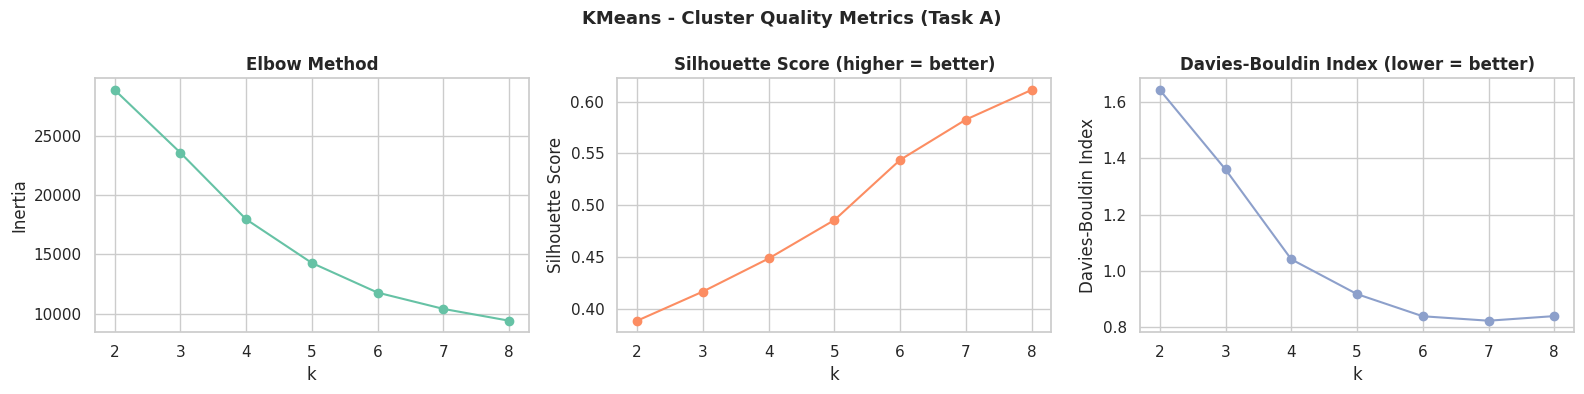

Best k by silhouette:      8
Best k by Davies-Bouldin:  7


In [8]:
k_range = unsup_cfg['kmeans_k_range']
inertias    = []
silhouettes = []
db_scores   = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=unsup_cfg['random_state'], n_init=10)
    labels = km.fit_predict(X_a_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_a_scaled, labels, sample_size=2000,
                                        random_state=unsup_cfg['random_state']))
    db_scores.append(davies_bouldin_score(X_a_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette(NB_CONFIG['palette'])

axes[0].plot(k_range, inertias, marker='o', color=palette[0])
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(k_range, silhouettes, marker='o', color=palette[1])
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')

axes[2].plot(k_range, db_scores, marker='o', color=palette[2])
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')

fig.suptitle('KMeans - Cluster Quality Metrics (Task A)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_sil = k_range[np.argmax(silhouettes)]
best_k_db  = k_range[np.argmin(db_scores)]
print(f'Best k by silhouette:      {best_k_sil}')
print(f'Best k by Davies-Bouldin:  {best_k_db}')

## A.4 KMeans - Fit Best k

In [9]:
# Use silhouette score to select k (more interpretable than DB index alone)
best_k = best_k_sil
print(f'Fitting KMeans with k={best_k}')

km_a = KMeans(n_clusters=best_k, random_state=unsup_cfg['random_state'], n_init=10)
labels_km_a = km_a.fit_predict(X_a_scaled)

X_a_clustered = X_a.copy()
X_a_clustered['cluster'] = labels_km_a

print(f'Silhouette score: {silhouette_score(X_a_scaled, labels_km_a):.4f}')
print(f'Davies-Bouldin:   {davies_bouldin_score(X_a_scaled, labels_km_a):.4f}')

Fitting KMeans with k=8
Silhouette score: 0.6132
Davies-Bouldin:   0.8400


In [10]:
# Profile each cluster by mean feature values
profile = X_a_clustered.groupby('cluster')[available_a].mean().round(2)
print('Cluster profiles (mean feature values):')
profile

Cluster profiles (mean feature values):


,number_of_casualties,number_of_vehicles,speed_limit,road_type,weather_conditions,light_conditions,road_surface_conditions
cluster,,,,,,,
0,1.0,0.5,33.07,2.34,1.19,1.00,1.26
1,1.0,0.5,30.58,6.19,1.53,1.00,2.08
2,1.0,0.5,30.49,6.20,1.04,4.15,1.00
3,1.0,0.5,30.40,6.20,1.03,1.00,1.00
4,1.0,0.5,32.57,5.44,7.65,2.40,1.96
5,1.0,0.5,32.81,2.34,1.32,4.08,1.51
6,1.0,0.5,61.97,4.93,1.46,2.30,1.61
7,1.0,0.5,30.67,6.14,1.56,4.13,2.15


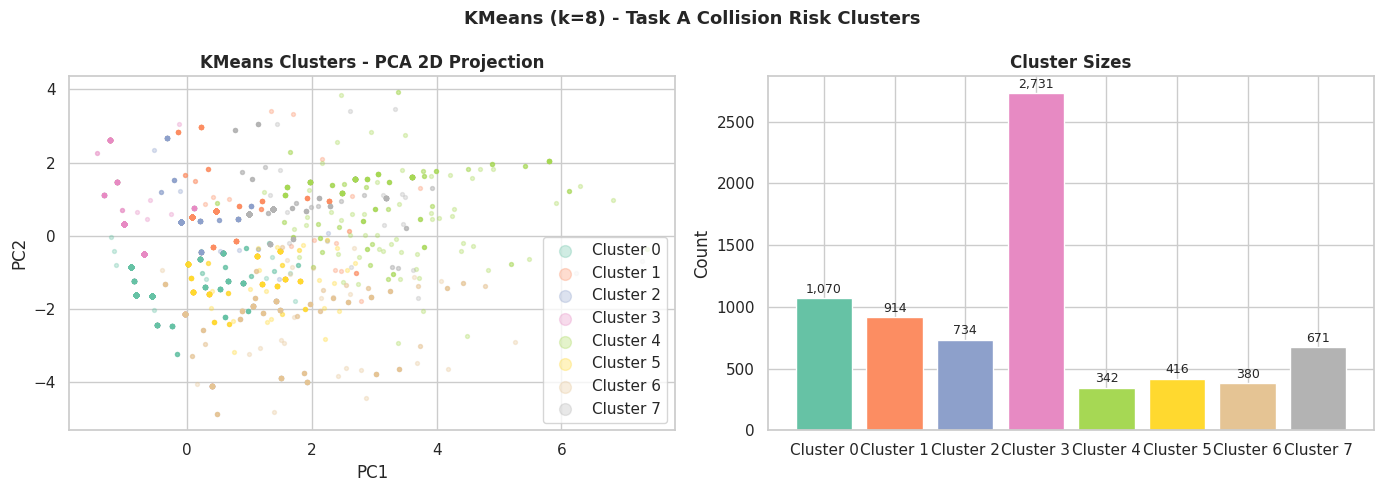

In [11]:
palette = sns.color_palette(NB_CONFIG['palette'], best_k)

fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))

# PCA 2D scatter colored by cluster
for cl in range(best_k):
    mask = labels_km_a == cl
    axes[0].scatter(X_a_2d[mask, 0], X_a_2d[mask, 1],
                    alpha=0.3, s=8, color=palette[cl], label=f'Cluster {cl}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('KMeans Clusters - PCA 2D Projection', fontweight='bold')
axes[0].legend(markerscale=3)

# Cluster size bar chart
cluster_counts = pd.Series(labels_km_a).value_counts().sort_index()
axes[1].bar([f'Cluster {i}' for i in cluster_counts.index],
            cluster_counts.values,
            color=palette, edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Cluster Sizes', fontweight='bold')
for _i, (bar, count) in enumerate(zip(axes[1].patches, cluster_counts.values, strict=False)):
    axes[1].annotate(f'{count:,}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9)

fig.suptitle(f'KMeans (k={best_k}) - Task A Collision Risk Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## A.5 DBSCAN

DBSCAN identifies clusters of arbitrary shape and marks low-density
points as noise (label=-1). Noise points in this context represent
collisions that do not fit any common risk pattern — potentially unusual
or genuinely atypical incidents.

In [12]:
db_a = DBSCAN(
    eps=unsup_cfg['dbscan_eps'],
    min_samples=unsup_cfg['dbscan_min_samples'],
)
labels_db_a = db_a.fit_predict(X_a_scaled)

summary_db_a = cluster_summary(labels_db_a, 'Task A - DBSCAN')

# Only compute scores on non-noise points
non_noise = labels_db_a != -1
if non_noise.sum() > 1 and len(set(labels_db_a[non_noise])) > 1:
    sil_db = silhouette_score(X_a_scaled[non_noise], labels_db_a[non_noise])
    db_idx = davies_bouldin_score(X_a_scaled[non_noise], labels_db_a[non_noise])
    print(f'  Silhouette (non-noise): {sil_db:.4f}')
    print(f'  Davies-Bouldin (non-noise): {db_idx:.4f}')
else:
    print('  Not enough non-noise clusters for silhouette/DB scores.')
    sil_db, db_idx = None, None

[Task A - DBSCAN]
  Clusters found: 101
  Noise points:   353 (4.9%)
  Cluster 0: 238 points (3.3%)
  Cluster 1: 165 points (2.3%)
  Cluster 2: 2,446 points (33.7%)
  Cluster 3: 358 points (4.9%)
  Cluster 4: 205 points (2.8%)
  Cluster 5: 10 points (0.1%)
  Cluster 6: 24 points (0.3%)
  Cluster 7: 276 points (3.8%)
  Cluster 8: 33 points (0.5%)
  Cluster 9: 26 points (0.4%)
  Cluster 10: 32 points (0.4%)
  Cluster 11: 408 points (5.6%)
  Cluster 12: 25 points (0.3%)
  Cluster 13: 330 points (4.5%)
  Cluster 14: 18 points (0.2%)
  Cluster 15: 45 points (0.6%)
  Cluster 16: 604 points (8.3%)
  Cluster 17: 21 points (0.3%)
  Cluster 18: 36 points (0.5%)
  Cluster 19: 128 points (1.8%)
  Cluster 20: 9 points (0.1%)
  Cluster 21: 34 points (0.5%)
  Cluster 22: 8 points (0.1%)
  Cluster 23: 52 points (0.7%)
  Cluster 24: 21 points (0.3%)
  Cluster 25: 50 points (0.7%)
  Cluster 26: 12 points (0.2%)
  Cluster 27: 37 points (0.5%)
  Cluster 28: 5 points (0.1%)
  Cluster 29: 6 points (0.1%)
  

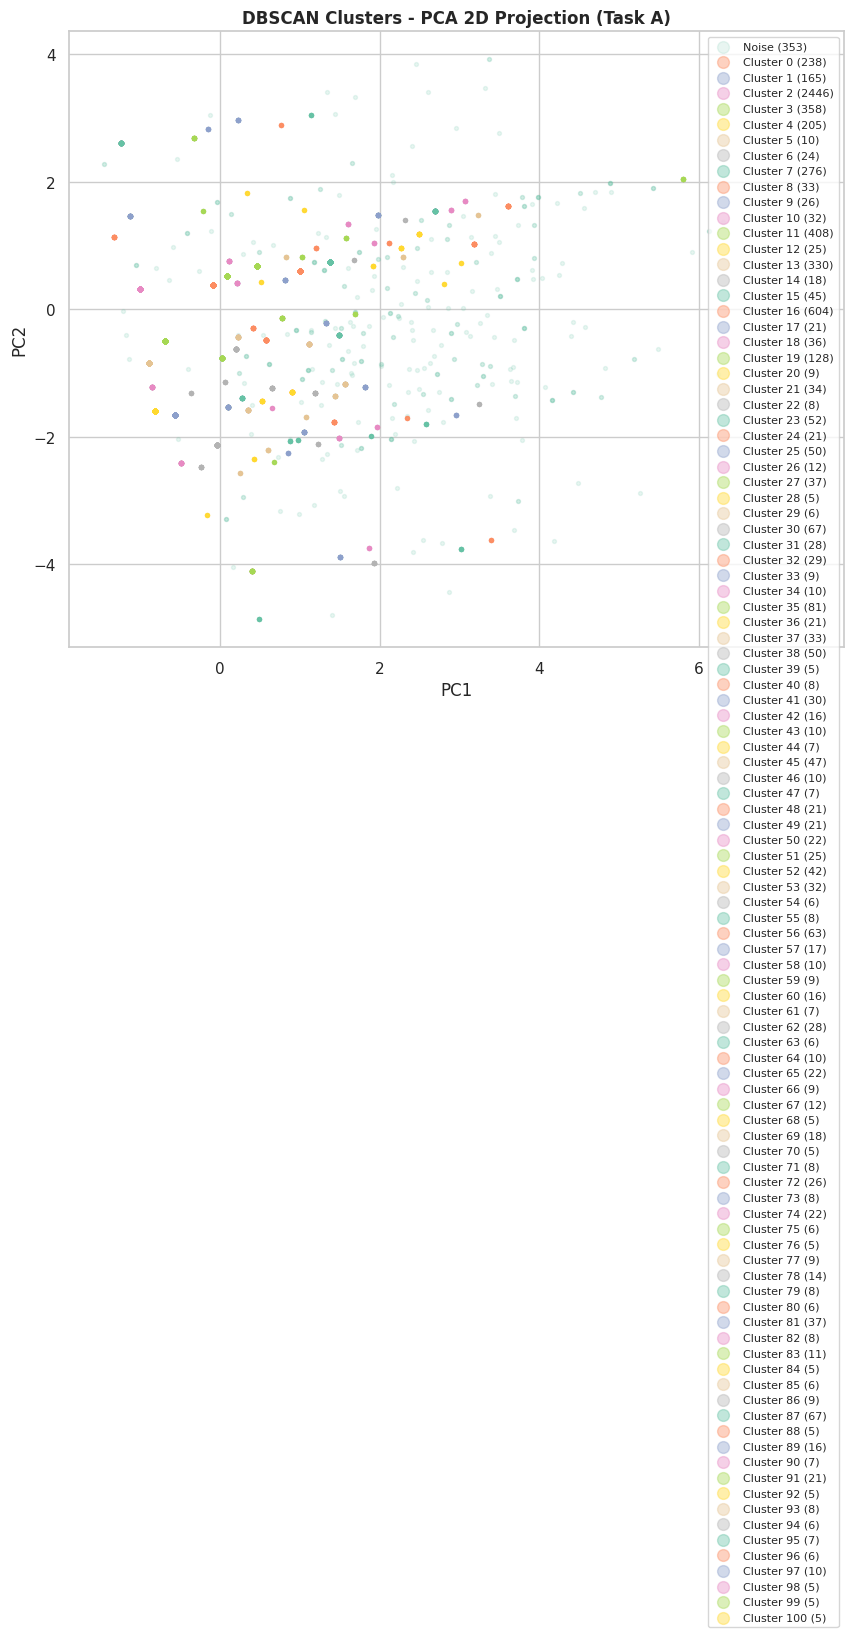

In [13]:
fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))

db_labels_unique = sorted(set(labels_db_a))
db_palette = sns.color_palette(NB_CONFIG['palette'], len(db_labels_unique))

for label, color in zip(db_labels_unique, db_palette, strict=False):
    mask = labels_db_a == label
    name = f'Noise ({mask.sum()})' if label == -1 else f'Cluster {label} ({mask.sum()})'
    alpha = 0.15 if label == -1 else 0.4
    ax.scatter(X_a_2d[mask, 0], X_a_2d[mask, 1],
               alpha=alpha, s=8, color=color, label=name)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('DBSCAN Clusters - PCA 2D Projection (Task A)', fontweight='bold')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

---
# Task B - Geospatial Hotspot Clustering

**Features:** easting and northing expressed as km offsets from Sheffield
city centre (OS grid ~435000E, ~387000N). Deliberately minimal — we want
geographic clusters, not feature clusters.

DBSCAN is particularly well suited here: accident hotspots have irregular
geographic shapes that density-based clustering handles naturally, and
isolated incidents are correctly flagged as noise rather than forced into
a cluster.

## B.1 Feature Construction and Scaling

In [14]:
# Sheffield OS grid centroid
SHEFFIELD_EASTING  = 435000
SHEFFIELD_NORTHING = 387000

X_b = pd.DataFrame({
    'easting_km':  (df['location_easting_osgr']  - SHEFFIELD_EASTING)  / 1000,
    'northing_km': (df['location_northing_osgr'] - SHEFFIELD_NORTHING) / 1000,
}).dropna()

# Carry severity for the overlay plot - align index
severity_b = df.loc[X_b.index, 'collision_severity']

print(f'Task B spatial matrix: {X_b.shape}')
print(f'Easting range:  {X_b["easting_km"].min():.1f} to {X_b["easting_km"].max():.1f} km')
print(f'Northing range: {X_b["northing_km"].min():.1f} to {X_b["northing_km"].max():.1f} km')

Task B spatial matrix: (7258, 2)
Easting range:  -435.0 to -435.0 km
Northing range: -387.0 to -387.0 km


In [15]:
scaler_b = StandardScaler()
X_b_scaled = scaler_b.fit_transform(X_b)

## B.2 KMeans - Elbow and Cluster Selection

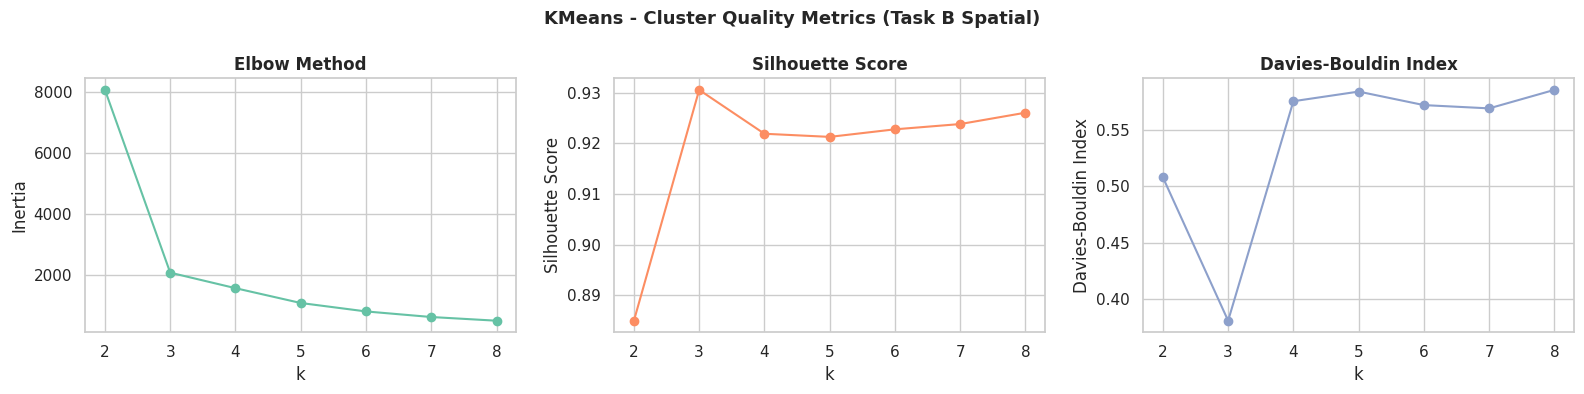

Best k by silhouette: 3


In [16]:
k_range = unsup_cfg['kmeans_k_range']
inertias_b    = []
silhouettes_b = []
db_scores_b   = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=unsup_cfg['random_state'], n_init=10)
    labels = km.fit_predict(X_b_scaled)
    inertias_b.append(km.inertia_)
    silhouettes_b.append(silhouette_score(X_b_scaled, labels, sample_size=2000,
                                          random_state=unsup_cfg['random_state']))
    db_scores_b.append(davies_bouldin_score(X_b_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette(NB_CONFIG['palette'])

axes[0].plot(k_range, inertias_b, marker='o', color=palette[0])
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(k_range, silhouettes_b, marker='o', color=palette[1])
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')

axes[2].plot(k_range, db_scores_b, marker='o', color=palette[2])
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index', fontweight='bold')

fig.suptitle('KMeans - Cluster Quality Metrics (Task B Spatial)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_b = k_range[np.argmax(silhouettes_b)]
print(f'Best k by silhouette: {best_k_b}')

## B.3 KMeans - Fit Best k

In [17]:
km_b = KMeans(n_clusters=best_k_b, random_state=unsup_cfg['random_state'], n_init=10)
labels_km_b = km_b.fit_predict(X_b_scaled)

print(f'KMeans spatial clusters (k={best_k_b}):')
print(f'  Silhouette: {silhouette_score(X_b_scaled, labels_km_b):.4f}')
print(f'  Davies-Bouldin: {davies_bouldin_score(X_b_scaled, labels_km_b):.4f}')

KMeans spatial clusters (k=3):
  Silhouette: 0.9292
  Davies-Bouldin: 0.3812


## B.4 Spatial Maps

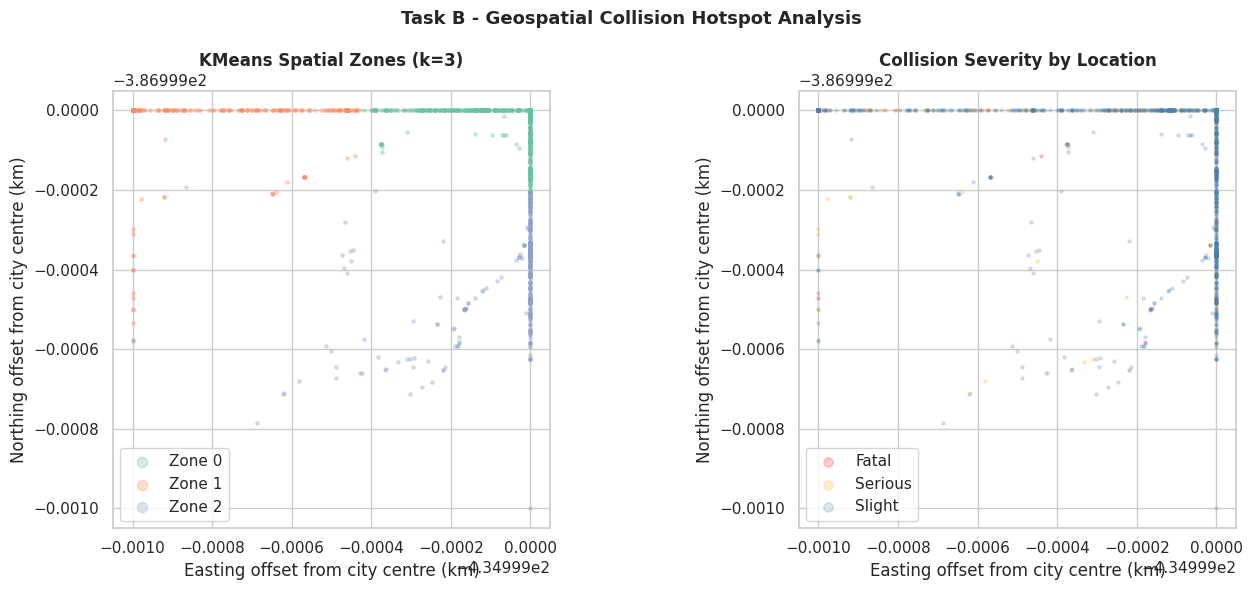

In [18]:
palette_b = sns.color_palette(NB_CONFIG['palette'], best_k_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: KMeans spatial clusters
for cl in range(best_k_b):
    mask = labels_km_b == cl
    axes[0].scatter(
        X_b.loc[X_b.index[mask], 'easting_km'],
        X_b.loc[X_b.index[mask], 'northing_km'],
        alpha=0.3, s=6, color=palette_b[cl], label=f'Zone {cl}'
    )
axes[0].set_xlabel('Easting offset from city centre (km)')
axes[0].set_ylabel('Northing offset from city centre (km)')
axes[0].set_title(f'KMeans Spatial Zones (k={best_k_b})', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_aspect('equal')

# Right: severity overlay on best clustering
sev_colors = {1: 'red', 2: 'orange', 3: 'steelblue'}
sev_labels_map = NB_CONFIG['severity_labels']
for sev in sorted(sev_colors):
    mask = severity_b.values == sev
    axes[1].scatter(
        X_b['easting_km'].values[mask],
        X_b['northing_km'].values[mask],
        alpha=0.2, s=5, color=sev_colors[sev],
        label=sev_labels_map[sev]
    )
axes[1].set_xlabel('Easting offset from city centre (km)')
axes[1].set_ylabel('Northing offset from city centre (km)')
axes[1].set_title('Collision Severity by Location', fontweight='bold')
axes[1].legend(markerscale=3)
axes[1].set_aspect('equal')

fig.suptitle('Task B - Geospatial Collision Hotspot Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## B.5 DBSCAN - Spatial Hotspots

[Task B - DBSCAN Spatial]
  Clusters found: 6
  Noise points:   21 (0.3%)
  Cluster 0: 7,183 points (99.0%)
  Cluster 1: 10 points (0.1%)
  Cluster 2: 11 points (0.2%)
  Cluster 3: 20 points (0.3%)
  Cluster 4: 6 points (0.1%)
  Cluster 5: 7 points (0.1%)


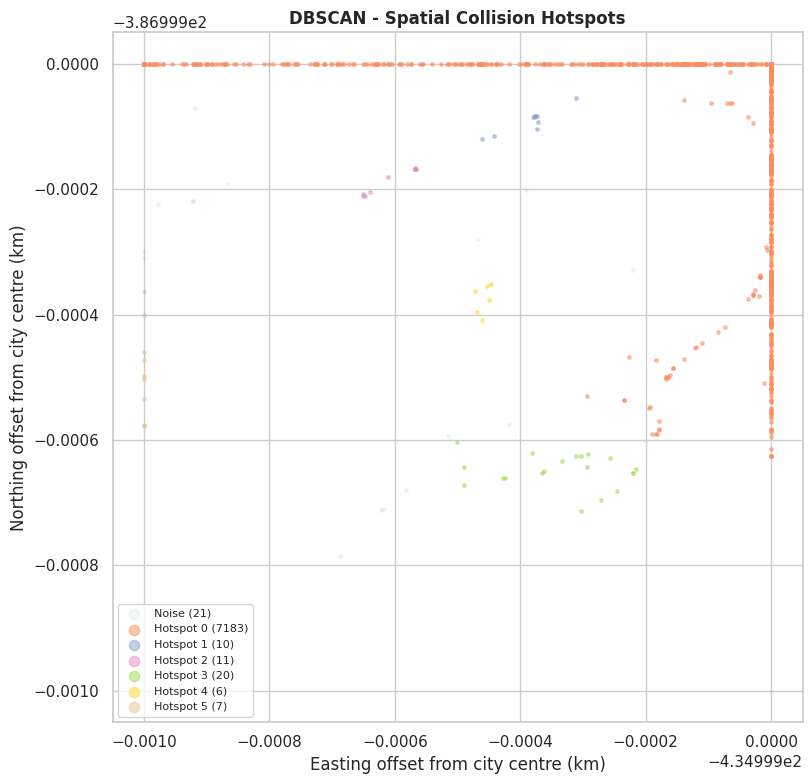

In [19]:
db_b = DBSCAN(
    eps=unsup_cfg['dbscan_eps'],
    min_samples=unsup_cfg['dbscan_min_samples'],
)
labels_db_b = db_b.fit_predict(X_b_scaled)

summary_db_b = cluster_summary(labels_db_b, 'Task B - DBSCAN Spatial')

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
db_unique_b = sorted(set(labels_db_b))
db_pal_b = sns.color_palette(NB_CONFIG['palette'], len(db_unique_b))

for label, color in zip(db_unique_b, db_pal_b, strict=False):
    mask = labels_db_b == label
    name = f'Noise ({mask.sum()})' if label == -1 else f'Hotspot {label} ({mask.sum()})'
    alpha = 0.1 if label == -1 else 0.5
    ax.scatter(
        X_b['easting_km'].values[mask],
        X_b['northing_km'].values[mask],
        alpha=alpha, s=6, color=color, label=name
    )
ax.set_xlabel('Easting offset from city centre (km)')
ax.set_ylabel('Northing offset from city centre (km)')
ax.set_title('DBSCAN - Spatial Collision Hotspots', fontweight='bold')
ax.legend(markerscale=3, fontsize=8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
# Persist Unsupervised Outputs

In [20]:
output_dir = NOTEBOOKS_DIR / 'stage_outputs'
os.makedirs(output_dir, exist_ok=True)

output_path = output_dir / 'unsupervised.pkl'
with open(output_path, 'wb') as f:
    pickle.dump({
        'task_a': {
            'kmeans_labels':   labels_km_a,
            'dbscan_labels':   labels_db_a,
            'best_k':          best_k,
            'silhouettes':     silhouettes,
            'db_scores':       db_scores,
            'k_range':         k_range,
            'pca_2d':          X_a_2d,
            'cluster_profile': profile,
            'X_a':             X_a,
        },
        'task_b': {
            'kmeans_labels':  labels_km_b,
            'dbscan_labels':  labels_db_b,
            'best_k':         best_k_b,
            'silhouettes':    silhouettes_b,
            'db_scores':      db_scores_b,
            'k_range':        k_range,
            'X_spatial':      X_b,
            'severity':       severity_b,
        },
    }, f)

print(f'Unsupervised outputs saved to: {output_path}')

Unsupervised outputs saved to: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/unsupervised.pkl
